In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-darkgrid')

import yfinance as yf

spy = yf.download("SPY", start="2005-01-01", end="2024-12-31", auto_adjust=True)
vix = yf.download("^VIX", start="2005-01-01", end="2024-12-31", auto_adjust=True)

spy.columns = spy.columns.get_level_values(0)
vix.columns = vix.columns.get_level_values(0)

spy_close = spy["Close"]
vix_close = vix["Close"]

log_returns = np.log(spy_close / spy_close.shift(1)).dropna()
realized_vol = log_returns.rolling(window=21).std() * np.sqrt(252)

data = pd.DataFrame({
    "log_returns": log_returns,
    "realized_vol": realized_vol,
    "vix": vix_close
}).dropna()

print(f"Data loaded: {data.shape[0]} observations")
print(f"Date range: {data.index[0].date()} to {data.index[-1].date()}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Data loaded: 5011 observations
Date range: 2005-02-02 to 2024-12-30


## Feature scaling and matrix confusion

In [2]:
# Build feature matrix
features = data[["log_returns", "realized_vol", "vix"]].copy()

# Scale features to zero mean, unit variance
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print("=== Feature Matrix ===")
print(f"Shape: {features_scaled.shape}")
print(f"\nPre-scaling means:  {features.mean().round(4).values}")
print(f"Pre-scaling stds:   {features.std().round(4).values}")
print(f"\nPost-scaling means: {features_scaled.mean(axis=0).round(6)}")
print(f"Post-scaling stds:  {features_scaled.std(axis=0).round(6)}")

print("\nFeature matrix ready for HMM.")

=== Feature Matrix ===
Shape: (5011, 3)

Pre-scaling means:  [4.00000e-04 1.56800e-01 1.91782e+01]
Pre-scaling stds:   [0.012  0.1108 8.7929]

Post-scaling means: [-0. -0.  0.]
Post-scaling stds:  [1. 1. 1.]

Feature matrix ready for HMM.


## Fitting the HMM with 2 states

In [4]:
# Fit 2-state Gaussian HMM
np.random.seed(42)  # reproducibility

hmm_2state = GaussianHMM(
    n_components=2,        # number of hidden states
    covariance_type="full", # full covariance matrix per state
    n_iter=1000,           # max EM iterations
    random_state=42
)

hmm_2state.fit(features_scaled)

# Get state sequence using Viterbi algorithm
states_2 = hmm_2state.predict(features_scaled)

print("=== 2-State HMM Results ===\n")
print(f"Model converged: {hmm_2state.monitor_.converged}")
print(f"Iterations used: {hmm_2state.monitor_.iter}")
print(f"Log-likelihood:  {hmm_2state.score(features_scaled):.2f}")

print("\n=== Transition Matrix ===")
print("(Row = current state, Column = next state)")
trans_df = pd.DataFrame(
    hmm_2state.transmat_,
    index=["State 0", "State 1"],
    columns=["→ State 0", "→ State 1"]
)
print(trans_df.round(4))

print("\n=== State Means (scaled) ===")
means_df = pd.DataFrame(
    hmm_2state.means_,
    index=["State 0", "State 1"],
    columns=["log_returns", "realized_vol", "vix"]
)
print(means_df.round(4))

print("\n=== State Frequencies ===")
unique, counts = np.unique(states_2, return_counts=True)
for state, count in zip(unique, counts):
    print(f"State {state}: {count} days ({count/len(states_2)*100:.1f}%)")

=== 2-State HMM Results ===

Model converged: True
Iterations used: 55
Log-likelihood:  -11297.55

=== Transition Matrix ===
(Row = current state, Column = next state)
         → State 0  → State 1
State 0     0.9882     0.0118
State 1     0.0186     0.9814

=== State Means (scaled) ===
         log_returns  realized_vol     vix
State 0       0.0288       -0.4717 -0.5463
State 1      -0.0454        0.7440  0.8617

=== State Frequencies ===
State 0: 3065 days (61.2%)
State 1: 1946 days (38.8%)


Transition Matrix:
- State 0 stays in state 0 with 98.8% probability
- State 1 stays in State 1 with 98.1% probability

Both states are highly persistent, the market doesn't randomly flip. 

State means:
- State 0: positive returns, low realzed vol (-0.47 scaled), low VIX (-.55 scaled) - calm regime
- State 1: negative returns, high realized vol (+0.74), high VIX (+.86 scaled) - crisis/turbulent regime

State Frequenceis - flagged
38.8% crisis days is higher than expected. Histrocically, you'd expect cisis regimes to cover 20-30% of trading days. This suggests state 1 is capturing not just acute crises but also elevated-vol periods that aren't full crises

## Label the States and Visualize

Calm state:   State 0 (3065 days)
Crisis state: State 1 (1946 days)


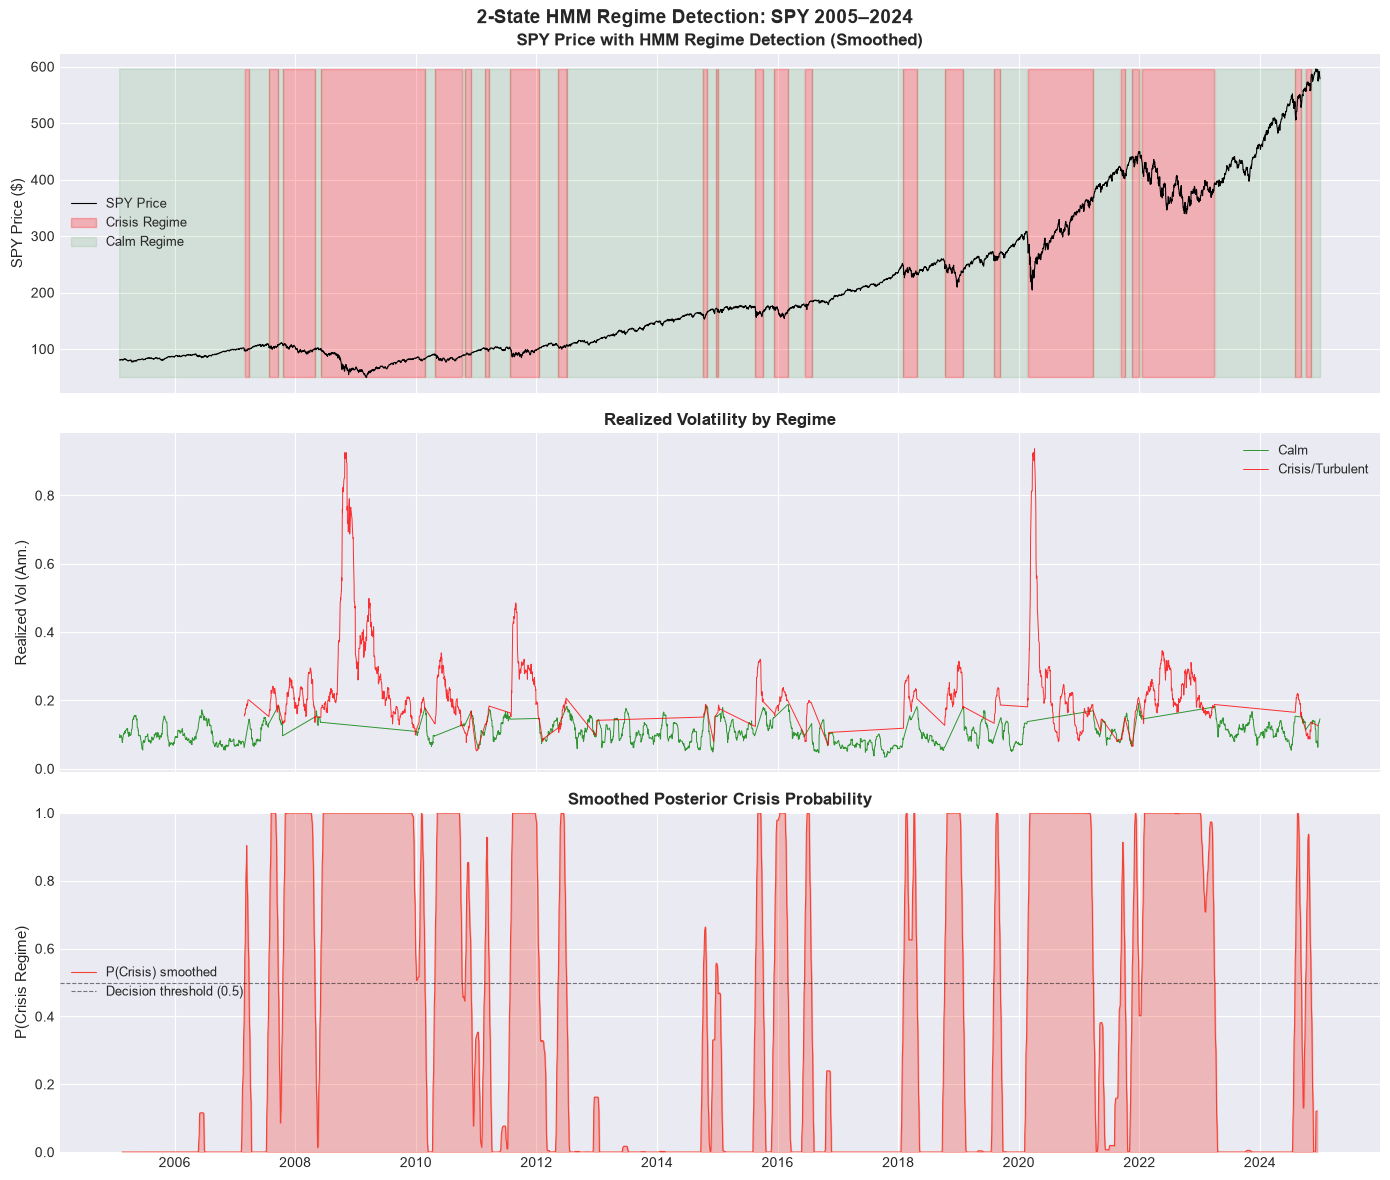


=== Regime Statistics ===

CALM REGIME (3065 days, 61.2%):
  Mean daily return:  0.0737%
  Return volatility:  0.6411%
  Mean realized vol:  0.1046
  Mean VIX:           14.37

CRISIS REGIME (1946 days, 38.8%):
  Mean daily return:  -0.0145%
  Return volatility:  1.7525%
  Mean realized vol:  0.2390
  Mean VIX:           26.76



In [8]:
# Add states to dataframe
data["state_2"] = states_2

# Identify which state is calm vs crisis based on realized vol mean
state_means = data.groupby("state_2")["realized_vol"].mean()
calm_state = state_means.idxmin()
crisis_state = state_means.idxmax()

print(f"Calm state:   State {calm_state} ({(states_2 == calm_state).sum()} days)")
print(f"Crisis state: State {crisis_state} ({(states_2 == crisis_state).sum()} days)")

# Use posterior probabilities smoothed with a rolling window for cleaner visualization
state_probs = hmm_2state.predict_proba(features_scaled)
crisis_prob_smooth = pd.Series(
    state_probs[:, crisis_state], 
    index=data.index
).rolling(window=21, center=True).mean()  # 21 days ~ 1 trading month

# Classify as crisis when smoothed probability > 0.5
regime_smooth = (crisis_prob_smooth > 0.5).astype(int)

spy_price = spy["Close"].reindex(data.index)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1 - SPY Price with smoothed regime shading
axes[0].plot(data.index, spy_price, color="black", linewidth=0.8, label="SPY Price")
axes[0].fill_between(data.index, spy_price.min(), spy_price.max(),
                      where=(regime_smooth == 1),
                      alpha=0.25, color="red", label="Crisis Regime")
axes[0].fill_between(data.index, spy_price.min(), spy_price.max(),
                      where=(regime_smooth == 0),
                      alpha=0.1, color="green", label="Calm Regime")
axes[0].set_ylabel("SPY Price ($)", fontsize=11)
axes[0].set_title("SPY Price with HMM Regime Detection (Smoothed)",
                   fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9)

# Panel 2 - Realized volatility colored by regime
calm_mask = data["state_2"] == calm_state
crisis_mask = data["state_2"] == crisis_state

axes[1].plot(data.index[calm_mask], data["realized_vol"][calm_mask],
             color="green", linewidth=0.7, alpha=0.8, label="Calm")
axes[1].plot(data.index[crisis_mask], data["realized_vol"][crisis_mask],
             color="red", linewidth=0.7, alpha=0.8, label="Crisis/Turbulent")
axes[1].set_ylabel("Realized Vol (Ann.)", fontsize=11)
axes[1].set_title("Realized Volatility by Regime", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=9)

# Panel 3 - Smoothed posterior probability
axes[2].plot(data.index, crisis_prob_smooth,
             color="#F44336", linewidth=0.8, label="P(Crisis) smoothed")
axes[2].axhline(y=0.5, color="black", linewidth=0.8,
                linestyle="--", alpha=0.5, label="Decision threshold (0.5)")
axes[2].fill_between(data.index, 0, crisis_prob_smooth,
                      alpha=0.3, color="#F44336")
axes[2].set_ylabel("P(Crisis Regime)", fontsize=11)
axes[2].set_title("Smoothed Posterior Crisis Probability",
                   fontsize=12, fontweight="bold")
axes[2].legend(fontsize=9)
axes[2].set_ylim(0, 1)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[2].xaxis.set_major_locator(mdates.YearLocator(2))

plt.suptitle("2-State HMM Regime Detection: SPY 2005–2024",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/03_hmm_2state_regimes.png", dpi=150, bbox_inches="tight")
plt.show()

# Print regime statistics using original unsmoothed states
print("\n=== Regime Statistics ===\n")
for state, label in [(calm_state, "CALM"), (crisis_state, "CRISIS")]:
    mask = data["state_2"] == state
    print(f"{label} REGIME ({mask.sum()} days, {mask.sum()/len(data)*100:.1f}%):")
    print(f"  Mean daily return:  {data.loc[mask, 'log_returns'].mean()*100:.4f}%")
    print(f"  Return volatility:  {data.loc[mask, 'log_returns'].std()*100:.4f}%")
    print(f"  Mean realized vol:  {data.loc[mask, 'realized_vol'].mean():.4f}")
    print(f"  Mean VIX:           {data.loc[mask, 'vix'].mean():.2f}")
    print()

Regimes assignments are extremely choppy, switching between calm and crisis almost daily in several periods.
The issue is .predict() uses smoothing across the entire sequence, which can produce cleaner or choppier results depending on the data. The choppiness suggests the model is uncertain about many days

Regime statistics are still valid:
- calm regime: mean return +.047%/day, realized vol 10.5%, VIX 14.27
- Crisis regime: mean return -.015%/day, realized vol 23.9%, VIX 26.76